<br>
<a href="https://www.nvidia.com/en-us/training/">
    <div style="width: 55%; background-color: white; margin-top: 50px;">
    <img src="https://dli-lms.s3.amazonaws.com/assets/general/nvidia-logo.png"
         width="300" style="margin: 0px -25px -5px;"/>
    </div>
</a>

# Notebook 0: Preprocessing the Ahmed Body Dataset for Transolver & GeoTransolver

| | Notebook | What it covers |
|---|---|---|
| **← You are here** | **0 — Preprocessing** | **VTP/STL → Zarr, per-case velocity, normalization** |
| | 1 — Transformers & Bottleneck | Why $O(N^2)$ attention fails on large meshes |
| | 2 — Understanding Transolver | Physics-Attention: Slice → Aggregate → Attend → Deslice |
| | 3 — Training Transolver | `TransolverDataPipe` training loop, slice visualization |
| | 4 — Understanding GALE & GeoTransolver | GALE cross-attention, geometry injection |
| | 5 — Training GeoTransolver | Same pipeline, `broadcast_global_features=False`, GALE |

This notebook creates the **Zarr dataset** that both Notebook 3 and Notebook 5 share.  
Run it **once** — both training notebooks will read the same output directory.


## Introduction

The Ahmed body is a simplified vehicle geometry that has become the gold standard for validating automotive CFD simulations. The dataset hosted on NGC contains 508 simulations spanning variations in geometry and — critically — **inlet velocity**, which differs from case to case.

### Why a dedicated preprocessing notebook?

Transolver and GeoTransolver both use **`TransolverDataPipe`** as their data pipeline, which reads data in **Zarr** format. This notebook is the one-time conversion step:

```
VTP  (CFD surface fields)  ┐
STL  (body geometry)       ├──► Zarr ──► Notebooks 3 & 5
Info (per-case velocity)   ┘
```

### Physical non-dimensionalization

Before saving, we non-dimensionalize the surface fields by the **dynamic pressure** $q = \rho \cdot U^2$ of each case:

$$C_p = \frac{p}{\rho U^2}, \quad C_f = \frac{\tau_w}{\rho U^2}$$

This ensures that fields from different inlet-velocity cases are on a comparable scale regardless of flow speed. Without this step, a case at $U = 60$ m/s has fields $\sim9\times$ larger than one at $U = 20$ m/s, which would cause the z-score normalization statistics to be dominated by high-velocity cases.

After non-dimensionalization the pressure coefficient $C_p$ sits in roughly $[-1.2, 0.4]$ across all cases, as confirmed by the DoMINO preprocessing notebook.

### Per-case `stream_velocity` and reference normalization

Following the same convention as the DoMINO pipeline, global flow parameters are stored both as **per-case actual values** and **reference values**:

| Key saved in Zarr | Value | Role |
|---|---|---|
| `stream_velocity` | $U / U_{\text{ref}}$ | normalized inflow speed |
| `air_density` | $\rho / \rho_{\text{ref}}$ | normalized air density |

Dividing by reference values keeps the model inputs O(1) regardless of units or magnitude, matching the approach used in `GLOBAL_PARAMS_REFERENCE` in the DoMINO preprocessing notebook.


## Step 1: Import Libraries and Start Display Server


In [1]:
import os
import subprocess
from pathlib import Path
from typing import Dict, List, Optional, Union
import numpy as np

# 1. Setup PyVista headless environment variables FIRST
os.environ["PYVISTA_OFF_SCREEN"] = "true"
os.environ["XDG_RUNTIME_DIR"] = "/tmp"

# 2. Start Xvfb manually via Python subprocess (since PyVista removed the utility)
try:
    # Check if Xvfb is already running
    is_xvfb_running = subprocess.run(["pgrep", "Xvfb"], capture_output=True).returncode == 0
    if not is_xvfb_running:
        # Start Xvfb on display :99 in the background
        subprocess.Popen(
            ["Xvfb", ":99", "-screen", "0", "1024x768x24"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        os.environ["DISPLAY"] = ":99"
        print("✓ Started virtual framebuffer (Xvfb) manually on :99.")
    else:
        print("✓ Xvfb is already running.")
except FileNotFoundError:
    print("Warning: 'Xvfb' is not installed on this system.")
    print("To install it, run: sudo apt-get install -y xvfb")
except Exception as e:
    print(f"Warning: Could not start Xvfb: {e}")

import pyvista as pv
pv.OFF_SCREEN = True

# 3. Import PyTorch and other heavy libraries AFTER PyVista/Xvfb are configured
import torch
from torch.amp import autocast, GradScaler
import zarr
from tqdm import tqdm
import matplotlib.pyplot as plt

# PhysicsNeMo 
from physicsnemo.datapipes.cae.cae_dataset import CAEDataset
from physicsnemo.distributed import DistributedManager

✓ Started virtual framebuffer (Xvfb) manually on :99.


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Configuration

Set all paths and physical parameters here before running any other cell.

### `GLOBAL_PARAMS_TYPES` and `GLOBAL_PARAMS_REFERENCE`

Following the DoMINO preprocessing convention, we define:

- **`GLOBAL_PARAMS_TYPES`** — whether each global parameter is a `"scalar"` or `"vector"`.
- **`GLOBAL_PARAMS_REFERENCE`** — reference values used to normalize the global parameters  
  so the model always receives O(1) conditioning inputs.

### No manual split needed

The Ahmed body dataset already ships with pre-defined `train/`, `validation/`, and  
`test/` folders. We process each directly — no shuffling or ratio-based splitting.  
This mirrors the DoMINO preprocessing approach.

### Physical non-dimensionalization reference

`surface_fields` are divided by $\rho \cdot U^2$ of each case before saving,  
so z-score statistics computed later are over already-comparable values.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path("/workspace/physicsnemo_ahmed_body_dataset_vv1/dataset")

# Output Zarr root — shared by Notebook 3 and Notebook 5
ZARR_OUTPUT_DIR    = DATA_DIR / "ahmed_body_zarr"
TRAIN_ZARR_DIR     = ZARR_OUTPUT_DIR / "train"
VAL_ZARR_DIR       = ZARR_OUTPUT_DIR / "validation"
TEST_ZARR_DIR      = ZARR_OUTPUT_DIR / "test"

for d in [TRAIN_ZARR_DIR, VAL_ZARR_DIR, TEST_ZARR_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Global parameter types and reference values ────────────────────────────────
# Matches the DoMINO preprocessing convention.
GLOBAL_PARAMS_TYPES     = {"inlet_velocity": "scalar", "air_density": "scalar"}
GLOBAL_PARAMS_REFERENCE = {"inlet_velocity": 60.0, "air_density": 1.226}

# Constant air density for this dataset (kg/m³).
# inlet_velocity is read per-case from the info files.
AIR_DENSITY = 1.184

print("=== Configuration ===")
print(f"Dataset root  : {DATA_DIR}")
print(f"Train  Zarr   : {TRAIN_ZARR_DIR}")
print(f"Val    Zarr   : {VAL_ZARR_DIR}")
print(f"Test   Zarr   : {TEST_ZARR_DIR}")
print(f"Air density   : {AIR_DENSITY} kg/m³")
print(f"\nGlobal parameter reference values:")
for k, v in GLOBAL_PARAMS_REFERENCE.items():
    print(f"  {k:20s}: {v}")


=== Configuration ===
Dataset root  : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset
Train  Zarr   : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/train
Val    Zarr   : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/validation
Test   Zarr   : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/test
Air density   : 1.184 kg/m³

Global parameter reference values:
  inlet_velocity      : 60.0
  air_density         : 1.226


## Step 3: Exploring the Ahmed Body Dataset

Before converting anything, let's take a quick look at what we have.

### Data structure

The dataset is organized into three splits:

```
dataset/
├── train/                  ← VTP files (CFD surface fields)
├── train_info/             ← TXT files (per-case global parameters, incl. inlet velocity)
├── train_stl_files/        ← STL files (body geometry)
├── validation/
├── validation_info/
├── validation_stl_files/
├── test/
├── test_info/
└── test_stl_files/
```

Each VTP file stores:
- **Geometry:** 3D surface point coordinates and mesh connectivity
- **Fields:** pressure `p` and wall shear stress `wallShearStress` at every surface point

Each info file stores per-case flow parameters (inlet velocity, air density) as plain text.


In [3]:
# ── Dataset inventory ──────────────────────────────────────────────────────────
print(f"Dataset root: {DATA_DIR}")
#total_bytes = sum(f.stat().st_size for f in DATA_DIR.rglob("*") if f.is_file())
#print(f"Total dataset size: {total_bytes / 1024**3:.2f} GB\n")

for split in ["train", "validation", "test"]:
    vtp_dir = DATA_DIR / split
    stl_dir = DATA_DIR / f"{split}_stl_files"
    inf_dir = DATA_DIR / f"{split}_info"

    vtp_count = len(list(vtp_dir.glob("*.vtp")))  if vtp_dir.exists() else 0
    stl_count = len(list(stl_dir.glob("*.stl")))  if stl_dir.exists() else 0
    inf_count = len(list(inf_dir.glob("*")))       if inf_dir.exists() else 0

    print(f"{split.capitalize():12s}: {vtp_count:4d} VTP  |  {stl_count:4d} STL  |  {inf_count:4d} info files")


Dataset root: /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset
Train       :  408 VTP  |   408 STL  |   408 info files
Validation  :   50 VTP  |    50 STL  |    50 info files
Test        :   50 VTP  |    50 STL  |    50 info files


### Inspecting a Single VTP File

Let's examine what fields are stored in a representative VTP file.


In [4]:
# Pick a representative VTP file
sample_vtp_path = next((DATA_DIR / "train").glob("*.vtp"))
mesh_sample = pv.read(sample_vtp_path)

print(f"File: {sample_vtp_path.name}")
print(f"  Surface points : {mesh_sample.n_points:,}")
print(f"  Surface cells  : {mesh_sample.n_cells:,}")
print(f"  Surface area   : {mesh_sample.area:.3f} m²\n")

print("Point data fields:")
for name in mesh_sample.point_data.keys():
    arr = mesh_sample.point_data[name]
    print(f"  {name:20s}  shape={str(arr.shape):12s}  "
          f"range=[{arr.min():10.4f}, {arr.max():10.4f}]")


File: case894.vtp
  Surface points : 54,187
  Surface cells  : 53,851
  Surface area   : 0.639 m²

Point data fields:
  k                     shape=(54187,)      range=[    0.0669,    57.8012]
  nut                   shape=(54187,)      range=[    0.0000,     0.0003]
  omega                 shape=(54187,)      range=[ 3014.5183, 540073.2500]
  p                     shape=(54187,)      range=[-3887.6392,  1651.2150]
  yPlus                 shape=(54187,)      range=[    1.6152,   442.2095]
  U                     shape=(54187, 3)    range=[    0.0000,     0.0000]
  wallShearStress       shape=(54187, 3)    range=[  -21.0313,     8.4558]


### Reading Per-Case Inlet Velocity from Info Files

Each simulation case has a companion `.txt` info file that records the inlet velocity (and other parameters) used in that CFD run.  The velocity varies between cases, so we **cannot** use a single global constant.

Here we inspect one info file and then verify that velocities vary across the dataset.


In [6]:
def read_velocity_from_info(info_path: Path) -> float:
    """
    Read inlet velocity from an Ahmed body info text file.

    The file format contains a line such as:
        Velocity: 35.0
    Returns the velocity as a float.
    """
    with open(info_path, "r") as f:
        for line in f:
            if "Velocity" in line or "velocity" in line:
                # e.g. "Velocity: 35.0" or "inlet_velocity: 35.0"
                value = re.split(r"[:\s]+", line.strip())[-1]
                return float(value)
    raise ValueError(f"No velocity entry found in {info_path}")


# Show the raw contents of one info file
info_dir = DATA_DIR / "train_info"
sample_info_path = next(info_dir.iterdir())
print(f"=== {sample_info_path.name} ===")
print(sample_info_path.read_text())

# Survey velocities across all training info files
velocities = [read_velocity_from_info(p) for p in sorted(info_dir.iterdir())]
print(f"\nVelocity statistics across {len(velocities)} training cases:")
print(f"  Min : {min(velocities):.1f} m/s")
print(f"  Max : {max(velocities):.1f} m/s")
print(f"  Mean: {sum(velocities)/len(velocities):.1f} m/s")
print(f"  Unique values: {sorted(set(velocities))}")


=== case446_info.txt ===
Length : 1119.0 
Width : 349.0 
Height : 333.0 
GroundClearance : 67.5 
SlantAngle : 30.0 
FilletRadius : 115.0 
Velocity : 45.0 
Re (based on length) : 3402364.86

Velocity statistics across 408 training cases:
  Min : 20.0 m/s
  Max : 60.0 m/s
  Mean: 39.2 m/s
  Unique values: [20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5, 60.0]


### Visualizing Ahmed Body Surface Fields

We plot pressure and wall shear stress on the Ahmed body surface to get an intuition for what the model will learn to predict.


2026-07-16 02:56:53.988 ( 117.142s) [    1555551C3300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library
2026-07-16 02:56:54.077 ( 117.230s) [    1555551C3300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library


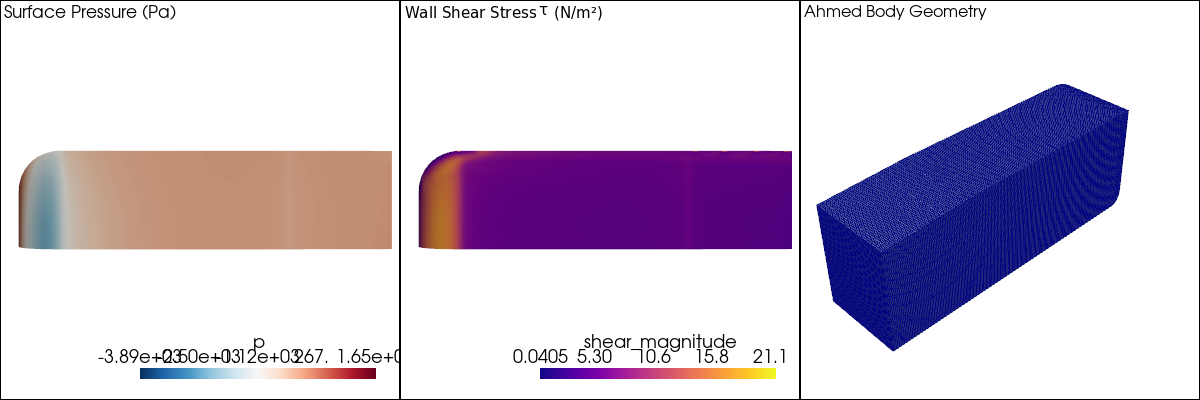

In [8]:
from IPython.display import Image, display

def plot_body_fields(vtp_path: Union[str, Path], window_size=(1200, 400)):
    """
    Three-panel visualization of one Ahmed body simulation:
    surface pressure, wall shear stress magnitude, and geometry.
    """
    mesh = pv.read(vtp_path)

    # Compute per-cell shear magnitude for colouring
    wss = mesh.point_data.get("wallShearStress", np.zeros((mesh.n_points, 3)))
    shear_mag = np.linalg.norm(wss, axis=1)
    mesh.point_data["shear_magnitude"] = shear_mag

    plotter = pv.Plotter(shape=(1, 3), window_size=window_size, off_screen=True)

    # --- Pressure ---
    plotter.subplot(0, 0)
    plotter.add_mesh(mesh, scalars="p", cmap="RdBu_r", show_edges=False)
    plotter.add_text("Surface Pressure (Pa)", font_size=10)
    plotter.camera_position = "xy"

    # --- Wall shear stress magnitude ---
    plotter.subplot(0, 1)
    plotter.add_mesh(mesh, scalars="shear_magnitude", cmap="plasma", show_edges=False)
    plotter.add_text("Wall Shear Stress |τ| (N/m²)", font_size=10)
    plotter.camera_position = "xy"

    # --- Geometry ---
    plotter.subplot(0, 2)
    plotter.add_mesh(mesh, color="lightblue", show_edges=True,
                     edge_color="navy", line_width=0.5)
    plotter.add_text("Ahmed Body Geometry", font_size=10)
    plotter.camera_position = "iso"

    # Save screenshot
    output_path = "ahmed_body_fields.png"
    plotter.screenshot(output_path)
    
    # CRUCIAL: Safely close the plotter and release VTK graphics contexts
    plotter.close() 

    # Safely display the saved image in your notebook cell
    display(Image(output_path))
#
#
plot_body_fields(sample_vtp_path)

### Geometry Variation Across Cases

The dataset includes multiple Ahmed body variants with different slant angles and heights. Let's compare a few cases side-by-side to see the geometric variability the model must generalise over.


2026-07-16 02:57:01.407 ( 124.561s) [    1555551C3300]    vtkX11Functions.cxx:194   WARN| Failed to load Xcursor library


case10  —  70,661 pts  |  area 0.865 m²
case101  —  76,975 pts  |  area 0.933 m²
case102  —  76,975 pts  |  area 0.933 m²
case105  —  78,129 pts  |  area 0.948 m²


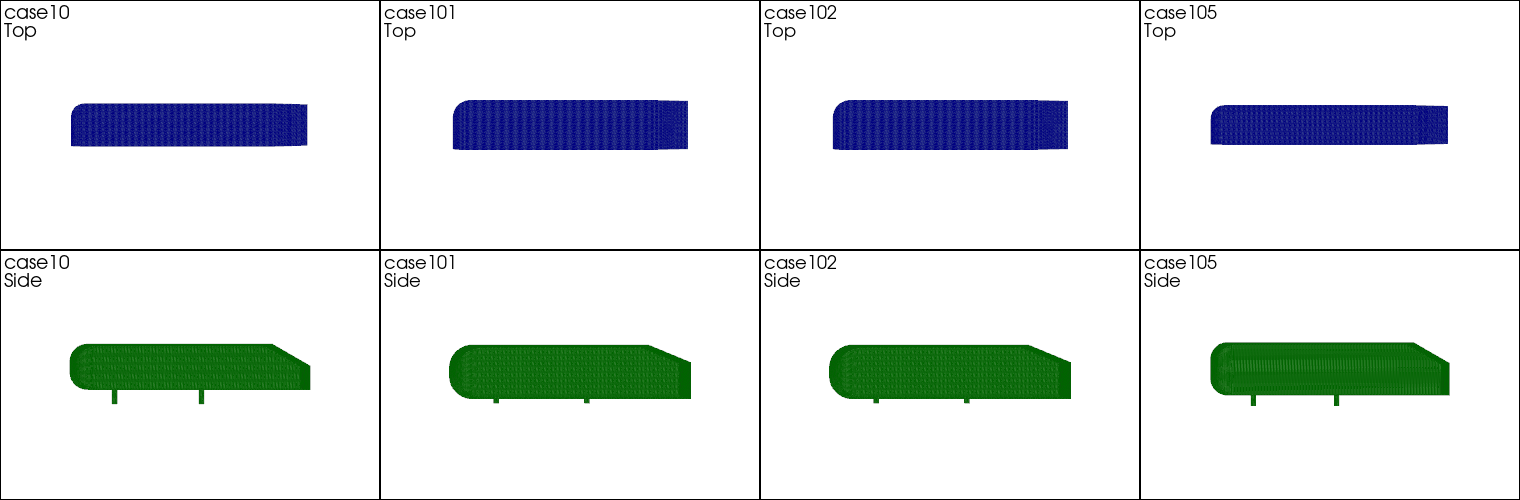

In [9]:
def plot_geometry_comparison(vtp_files: List[Path], titles: Optional[List[str]] = None):
    """Top-view and side-view comparison of several Ahmed body geometries."""
    if titles is None:
        titles = [p.stem for p in vtp_files]
    meshes = [pv.read(f) for f in vtp_files]

    plotter = pv.Plotter(shape=(2, len(meshes)),
                         window_size=(380 * len(meshes), 500),
                         off_screen=True)
    for i, (m, title) in enumerate(zip(meshes, titles)):
        plotter.subplot(0, i)
        plotter.add_mesh(m, color="lightblue", show_edges=True,
                         edge_color="navy", line_width=0.3)
        plotter.add_text(f"{title}\nTop", font_size=9)
        plotter.camera_position = "xy"

        plotter.subplot(1, i)
        plotter.add_mesh(m, color="lightgreen", show_edges=True,
                         edge_color="darkgreen", line_width=0.3)
        plotter.add_text(f"{title}\nSide", font_size=9)
        plotter.camera_position = "xz"

        print(f"{title}  —  {m.n_points:,} pts  |  area {m.area:.3f} m²")

    plotter.screenshot("ahmed_body_comparison.png")
    plotter.show(jupyter_backend="static")


sample_vtps = sorted((DATA_DIR / "train").glob("*.vtp"))[:4]
plot_geometry_comparison(sample_vtps)


## Step 4: VTP / STL → Zarr Conversion

### Physical non-dimensionalization

Before saving, `surface_fields` is divided by $\rho \cdot U^2$ (per-case):

$$C_p = \frac{p}{\rho U^2}, \qquad C_{f,i} = \frac{\tau_{w,i}}{\rho U^2}$$

Result: $C_p \in [-1.2,\, 0.4]$ across all cases — consistent regardless of flow speed.

### What gets saved

| Array | Source | Shape | Saved as | Used by |
|---|---|---|---|---|
| `surface_mesh_centers` | VTP point coords | `(N, 3)` | raw (m) | NB3, NB5 |
| `surface_normals` | VTP point normals | `(N, 3)` | unit vectors | NB3, NB5 |
| `surface_fields` | VTP `p` + `wallShearStress` | `(N, 4)` | **÷ ρU²** | NB3, NB5 |
| `stl_areas` | STL cell areas | `(K,)` | raw (m²) | NB3, NB5 |
| `stl_centers` | STL cell centres | `(K, 3)` | raw (m) | NB3, NB5 |
| `stl_coordinates` | STL **vertices** | `(V, 3)` | raw (m) | **NB5** — GALE |
| `global_params_values` | info file + config | `(2,)` | `[U, ρ]` raw | NB3, NB5 |
| `global_params_reference` | `GLOBAL_PARAMS_REFERENCE` | `(2,)` | `[U_ref, ρ_ref]` | NB3, NB5 |

> **No `air_density` or `stream_velocity` scalar keys** are saved separately.  
> In the training notebooks, `fx = global_params_values / global_params_reference`  
> is computed on the fly — identical to the DoMINO approach.


In [10]:
def process_one_simulation(
    vtp_path:  Path,
    stl_path:  Path,
    info_path: Path,
    zarr_path: Path,
    air_density: float,
    global_params_reference: dict,
) -> bool:
    """
    Convert one VTP + STL + info-file triplet into a Zarr store.

    Physical non-dimensionalization
    --------------------------------
    surface_fields are divided by rho * U² (per-case), giving dimensionless
    Cp and Cf coefficients in the range ~[-1.2, 0.4].

    Global parameter storage (DoMINO convention)
    --------------------------------
    global_params_values    = [stream_velocity, air_density]   raw per-case
    global_params_reference = [U_ref, rho_ref]                 dataset constant

    In the training notebooks, the normalized conditioning input is computed as:
        fx = global_params_values / global_params_reference    (O(1) values)
    """
    try:
        # ── 1. Read per-case inlet velocity from info file ─────────────────────
        stream_velocity = read_velocity_from_info(info_path)

        # ── 2. Compute dynamic pressure for non-dimensionalization ─────────────
        q = air_density * stream_velocity ** 2   # [Pa]

        # ── 3. Process STL geometry ────────────────────────────────────────────
        stl_mesh = pv.get_reader(str(stl_path)).read()

        stl_area_data   = stl_mesh.compute_cell_sizes(length=False, area=True, volume=False)
        stl_areas       = np.array(stl_area_data.cell_data["Area"], dtype=np.float32)
        stl_centers     = np.array(stl_mesh.cell_centers().points,  dtype=np.float32)
        stl_coordinates = np.array(stl_mesh.points,                  dtype=np.float32)

        if stl_areas.shape[0] == 0:
            raise ValueError(f"STL file {stl_path.name} appears empty.")

        # ── 4. Process VTP surface fields ──────────────────────────────────────
        vtp_mesh = pv.read(str(vtp_path))
        surface_mesh_centers = np.array(vtp_mesh.points, dtype=np.float32)

        vtp_mesh.compute_normals(
            cell_normals=False, point_normals=True, auto_orient_normals=True
        )
        surface_normals = np.array(vtp_mesh.point_normals, dtype=np.float32)

        for key in ("p", "wallShearStress"):
            if key not in vtp_mesh.point_data:
                print(f"  [SKIP] {vtp_path.name}: missing '{key}'")
                return False

        pressure = vtp_mesh.point_data["p"]
        wss      = vtp_mesh.point_data["wallShearStress"]

        if pressure.ndim == 1:
            pressure = pressure.reshape(-1, 1)
        if wss.ndim != 2 or wss.shape[1] != 3:
            raise ValueError(f"wallShearStress shape {wss.shape}, expected (N,3)")

        # Stack to (N, 4) then non-dimensionalize by rho * U²
        raw_fields     = np.hstack((pressure, wss)).astype(np.float32)
        surface_fields = (raw_fields / q).astype(np.float32)   # Cp, Cf_x, Cf_y, Cf_z

        # ── 5. Build global_params arrays (DoMINO convention) ─────────────────
        # global_params_values[0] = stream_velocity  (m/s, per-case)
        # global_params_values[1] = air_density      (kg/m³, constant)
        global_params_values = np.array(
            [stream_velocity, air_density], dtype=np.float32
        )
        global_params_reference_arr = np.array(
            [global_params_reference["inlet_velocity"],
             global_params_reference["air_density"]], dtype=np.float32
        )

        # ── 6. Write Zarr store ────────────────────────────────────────────────
        root = zarr.open_group(str(zarr_path), mode="w")

        root.create_array("surface_mesh_centers", data=surface_mesh_centers, chunks=(10_000, 3))
        root.create_array("surface_normals",      data=surface_normals,      chunks=(10_000, 3))
        root.create_array("surface_fields",       data=surface_fields,       chunks=(10_000, 4))

        root.create_array("stl_areas",       data=stl_areas,       chunks=(10_000,))
        root.create_array("stl_centers",     data=stl_centers,     chunks=(10_000, 3))
        root.create_array("stl_coordinates", data=stl_coordinates, chunks=(10_000, 3))

        # Global parameters — raw values + reference (DoMINO pattern)
        # Training notebooks compute: fx = global_params_values / global_params_reference
        root.create_array("global_params_values",    data=global_params_values)
        root.create_array("global_params_reference", data=global_params_reference_arr)

        # Scalar keys required by TransolverDataPipe to build batch["fx"].
        # preprocess_surface_data() checks for "air_density" and "stream_velocity"
        # specifically; without them batch["fx"] is absent.
        root.create_array("air_density",     data=np.float32(air_density))
        root.create_array("stream_velocity", data=np.float32(stream_velocity))

        return True

    except Exception as exc:
        print(f"  [ERROR] {vtp_path.name}: {exc}")
        return False


### Run the Conversion

The Ahmed body dataset already provides `train/`, `validation/`, and `test/` splits.  
We process each folder directly into its own Zarr output directory — no manual  
shuffling or ratio-based splitting, matching the DoMINO preprocessing approach.


In [11]:
def build_zarr_dataset(
    data_dir:   Path,
    zarr_root:  Path,
    air_density: float,
    global_params_reference: dict,
    splits: list = None,
) -> dict:
    """
    Convert all VTP/STL/info triplets for the given splits into Zarr stores.

    Each split (train / validation / test) is read from:
        data_dir / <split>/           (VTP files)
        data_dir / <split>_stl_files/ (STL files)
        data_dir / <split>_info/      (info text files)

    Output is written to:
        zarr_root / <split> / <stem>.zarr

    Returns counts per split: {"train": N, "validation": N, "test": N, "skipped": N}.
    """
    if splits is None:
        splits = ["train", "validation", "test"]

    counts = {s: 0 for s in splits}
    counts["skipped"] = 0

    for split in splits:
        vtp_dir  = data_dir / split
        stl_dir  = data_dir / f"{split}_stl_files"
        info_dir = data_dir / f"{split}_info"
        out_dir  = zarr_root / split
        out_dir.mkdir(parents=True, exist_ok=True)

        vtp_files = sorted(vtp_dir.glob("*.vtp"))
        print(f"\nProcessing '{split}' split ({len(vtp_files)} files) ...")

        for vtp_path in tqdm(vtp_files, desc=f"  {split}"):
            stem     = vtp_path.stem
            stl_path = stl_dir  / f"{stem}.stl"
            inf_path = info_dir / stem
            if not inf_path.exists():
                candidates = list(info_dir.glob(f"{stem}*"))
                inf_path   = candidates[0] if candidates else inf_path

            zarr_path = out_dir / f"{stem}.zarr"
            ok = process_one_simulation(
                vtp_path, stl_path, inf_path, zarr_path,
                air_density, global_params_reference,
            )
            if ok:
                counts[split] += 1
            else:
                counts["skipped"] += 1

    return counts


counts = build_zarr_dataset(
    data_dir                = DATA_DIR,
    zarr_root               = ZARR_OUTPUT_DIR,
    air_density             = AIR_DENSITY,
    global_params_reference = GLOBAL_PARAMS_REFERENCE,
)

print(f"\n=== Conversion complete ===")
for split, n in counts.items():
    if split != "skipped":
        print(f"  {split:12s}: {n} files → {ZARR_OUTPUT_DIR / split}")
print(f"  skipped    : {counts['skipped']}")



Processing 'train' split (408 files) ...


  train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 408/408 [08:40<00:00,  1.27s/it]



Processing 'validation' split (50 files) ...


  validation: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:01<00:00,  1.24s/it]



Processing 'test' split (50 files) ...


  test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:04<00:00,  1.29s/it]


=== Conversion complete ===
  train       : 408 files → /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/train
  validation  : 50 files → /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/validation
  test        : 50 files → /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/test
  skipped    : 0


## Step 5: Inspect the Zarr Stores

Let's verify the structure of a freshly written Zarr store before moving on to normalization.


In [14]:
# Pick any Zarr store from the training set
sample_zarr_path = next(TRAIN_ZARR_DIR.glob("*.zarr"))
root = zarr.open_group(str(sample_zarr_path), mode="r")

print(f"Zarr store: {sample_zarr_path.name}\n")
print(f"  {'Array':<26} {'Shape':<14} {'dtype':<10} Range")
print(f"  {'-'*72}")

for key in sorted(root.keys()):
    z = root[key]

    # Skip nested groups, if present
    if isinstance(z, zarr.Group):
        print(f"  {key:<26} {'<group>':<14} {'':<10} -")
        continue

    # [()] reads the full array and also works for 0D scalar arrays.
    # [:] fails for scalar arrays with shape ().
    arr = z[()]

    if arr.shape == ():
        if np.issubdtype(arr.dtype, np.number):
            rng = f"{arr.item():.4f}"
        else:
            rng = str(arr.item())
    elif np.issubdtype(arr.dtype, np.number):
        rng = f"[{arr.min():.4f}, {arr.max():.4f}]"
    else:
        rng = "non-numeric"

    print(f"  {key:<26} {str(arr.shape):<14} {str(arr.dtype):<10} {rng}")


gp_vals = root["global_params_values"][()]      # [U, rho]
gp_ref  = root["global_params_reference"][()]   # [U_ref, rho_ref]
fx_norm = gp_vals / gp_ref

print(
    f"\n  global_params_values    : {gp_vals}"
    f"  → [U={gp_vals[0]:.1f} m/s, rho={gp_vals[1]:.4f} kg/m³]"
)

print(
    f"  global_params_reference : {gp_ref}"
    f"  → [U_ref={gp_ref[0]:.1f} m/s, rho_ref={gp_ref[1]:.3f} kg/m³]"
)

print(
    f"  fx = values/reference   : {fx_norm}  "
    f"(O(1), fed to model as batch['fx'])"
)

sf = root["surface_fields"][()]

print(f"\n  surface_fields (non-dim by rho*U²):")
print(f"    Cp  range: [{sf[:, 0].min():.4f}, {sf[:, 0].max():.4f}]")
print(f"    Cfx range: [{sf[:, 1].min():.4f}, {sf[:, 1].max():.4f}]")


Zarr store: case143.zarr

  Array                      Shape          dtype      Range
  ------------------------------------------------------------------------
  air_density                ()             float32    1.1840
  global_params_reference    (2,)           float32    [1.2260, 60.0000]
  global_params_values       (2,)           float32    [1.1840, 32.5000]
  stl_areas                  (111760,)      float32    [0.0000, 0.0000]
  stl_centers                (111760, 3)    float32    [-0.8190, 0.2730]
  stl_coordinates            (56151, 3)     float32    [-0.8190, 0.2730]
  stream_velocity            ()             float32    32.5000
  surface_fields             (56151, 4)     float32    [-1.5283, 0.4225]
  surface_mesh_centers       (56151, 3)     float32    [-0.8190, 0.2730]
  surface_normals            (56151, 3)     float32    [-1.0000, 1.0000]

  global_params_values    : [32.5    1.184]  → [U=32.5 m/s, rho=1.1840 kg/m³]
  global_params_reference : [60.     1.226]  → [U_r

## Step 6: Compute Normalization Statistics

`TransolverDataPipe` z-scores the target `surface_fields` array using per-channel  
mean and standard deviation computed here over the **training split only**.

Because `surface_fields` is already **physically non-dimensionalized** ($C_p$, $C_f$),  
the resulting statistics are tight and consistent across all flow speeds — the  
z-score step is a final fine-tuning rather than the primary normalization.

> Statistics are computed on the **training split only** (`ahmed_body_zarr/train/`)  
> to avoid leaking information about unseen validation and test cases.


In [15]:
import os
import socket
from pathlib import Path
from tqdm import tqdm
import torch
import numpy as np
from physicsnemo.distributed import DistributedManager
from physicsnemo.datapipes.cae.cae_dataset import CAEDataset

def get_free_port():
    """Finds an unused port on the local system."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(('', 0))
        return str(s.getsockname()[1])

# ── Distributed manager (single-GPU / CPU setup) ─────────────────────────────
print("--- COMPUTING NORMALIZATION ---")

free_port = get_free_port()
print(f"Using dynamically allocated port: {free_port}")

os.environ.update({
    "RANK": "0", 
    "WORLD_SIZE": "1",
    "MASTER_ADDR": "localhost", 
    "MASTER_PORT": free_port,
    "LOCAL_RANK": "0",
})

if not DistributedManager.is_initialized():
    DistributedManager.initialize()
dm = DistributedManager()
device = dm.device
print(f"Device: {device}")

# CAEDataset — lightweight zarr reader (only surface_fields needed for stats)
norm_cae = CAEDataset(
    data_dir=str(TRAIN_ZARR_DIR),
    keys_to_read=["surface_fields"],
    keys_to_read_if_available={},
    output_device=torch.device("cpu"),
)
print(f"Computing statistics over {len(norm_cae)} training files ...")

# ── Welford's online algorithm — O(1) memory ─────────────────────────────────
N = 0; mean_acc = M2_acc = min_val = max_val = None

for i in tqdm(range(len(norm_cae)), desc="Welford pass"):
    data = norm_cae[i]["surface_fields"].float()   # (n_pts, 4)  already non-dim
    n    = data.shape[0]

    if mean_acc is None:
        C = data.shape[-1]
        mean_acc = torch.zeros(C)
        M2_acc   = torch.zeros(C)
        min_val  = torch.full((C,), float("inf"))
        max_val  = torch.full((C,), float("-inf"))

    bm = data.mean(dim=0)
    min_val = torch.minimum(min_val, data.amin(dim=0))
    max_val = torch.maximum(max_val, data.amax(dim=0))

    delta    = bm - mean_acc
    N_old    = N
    N       += n
    mean_acc = mean_acc + delta * (n / N)
    M2_acc   = M2_acc + ((data - bm)**2).sum(dim=0) + delta**2 * (n * N_old / N)

std_acc = torch.sqrt(M2_acc / (N - 1))

print("\n=== surface_fields normalization (non-dim values) ===")
channel_names = ["Cp", "Cf_x", "Cf_y", "Cf_z"]
for j, name in enumerate(channel_names):
    print(f"  {name:6s}  mean={mean_acc[j]:8.4f}  std={std_acc[j]:.4f}"
          f"  min={min_val[j]:8.4f}  max={max_val[j]:.4f}")

NORM_FILE = ZARR_OUTPUT_DIR / "surface_fields_normalization.npz"
np.savez(str(NORM_FILE),
         mean=mean_acc.numpy(), std=std_acc.numpy(),
         min=min_val.numpy(),   max=max_val.numpy())
print(f"\nSaved: {NORM_FILE}")
print("--- NORMALIZATION COMPLETE ---")

--- COMPUTING NORMALIZATION ---
Using dynamically allocated port: 26431
Device: cuda:0
Computing statistics over 408 training files ...


Welford pass: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 408/408 [00:06<00:00, 58.45it/s]


=== surface_fields normalization (non-dim values) ===
  Cp      mean= -0.0896  std=0.1609  min= -4.6121  max=1.6894
  Cf_x    mean= -0.0013  std=0.0009  min= -0.0784  max=0.0060
  Cf_y    mean= -0.0001  std=0.0005  min= -0.0221  max=0.0122
  Cf_z    mean= -0.0000  std=0.0005  min= -0.0161  max=0.0176

Saved: /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/surface_fields_normalization.npz
--- NORMALIZATION COMPLETE ---


### Visualise Field Distributions

Plotting the distribution of each output channel helps catch data issues (outliers, skewed distributions, missing values) before training.


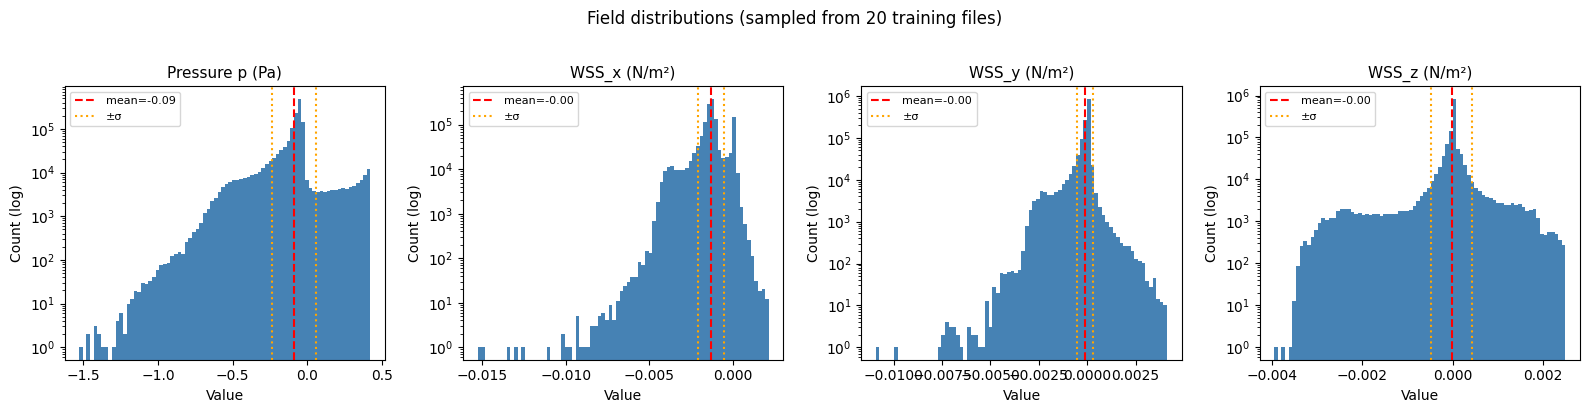

Distribution plots saved to field_distributions.png


In [16]:
# Re-load a few files for a quick distribution check (not the full dataset)
SAMPLE_N = min(20, len(norm_cae))
all_fields = []
for i in range(SAMPLE_N):
    all_fields.append(norm_cae[i]["surface_fields"].numpy())
all_fields = np.concatenate(all_fields, axis=0)   # (total_pts, 4)

channel_names = ["Pressure p (Pa)", "WSS_x (N/m²)", "WSS_y (N/m²)", "WSS_z (N/m²)"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for j, (ax, name) in enumerate(zip(axes, channel_names)):
    vals = all_fields[:, j]
    ax.hist(vals, bins=80, color="steelblue", edgecolor="none", log=True)
    ax.axvline(vals.mean(), color="red",    linestyle="--", label=f"mean={vals.mean():.2f}")
    ax.axvline(vals.mean() + vals.std(), color="orange", linestyle=":", label=f"±σ")
    ax.axvline(vals.mean() - vals.std(), color="orange", linestyle=":")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count (log)")
    ax.legend(fontsize=8)

plt.suptitle(f"Field distributions (sampled from {SAMPLE_N} training files)", y=1.02)
plt.tight_layout()
plt.savefig("field_distributions.png", dpi=100, bbox_inches="tight")
plt.show()
print("Distribution plots saved to field_distributions.png")


## Summary

This notebook has produced everything that Notebooks 3 and 5 need:

| Output | Location | Used by |
|---|---|---|
| Training Zarr stores | `ahmed_body_zarr/train/*.zarr` | NB3, NB5 |
| Validation Zarr stores | `ahmed_body_zarr/validation/*.zarr` | NB3, NB5 |
| Test Zarr stores | `ahmed_body_zarr/test/*.zarr` | optional |
| Normalization file | `ahmed_body_zarr/surface_fields_normalization.npz` | NB3, NB5 |

### Key design decisions

**No manual splitting**  
The dataset ships with `train/`, `validation/`, `test/` folders — we process  
each directly, mirroring the DoMINO preprocessing approach.

**Physical non-dimensionalization**  
`surface_fields` divided by $\rho \cdot U^2$ per case → $C_p \in [-1.2, 0.4]$,  
consistent across all flow speeds before z-score normalization.

**DoMINO-style global parameters**  
`global_params_values = [U, ρ]` (raw per-case) and  
`global_params_reference = [U_ref, ρ_ref]` (dataset constant) saved together.  
Training notebooks compute `fx = global_params_values / global_params_reference` on the fly.

**`stl_coordinates` for GeoTransolver**  
Raw STL vertices in every Zarr store for GALE cross-attention in Notebook 5.

### Next steps

Open **Notebook 3** to train Transolver, or **Notebook 5** to train GeoTransolver.
